# 05 — Cross-Day LOB Predictability Experiment

**Purpose**: Exploratory statistical test — do end-of-day LOB signals on day *t* carry predictive information about day *t+1* volatility and return magnitude?  
This is a signal validation exercise, **not a backtest**. No trading logic is implemented.

## Section 0 — Setup

In [1]:
import sys
import os
import pathlib

ROOT = pathlib.Path().resolve().parent
os.chdir(ROOT)

for p in [str(ROOT), str(ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

import load_data
load_data.DB_PATH = pathlib.Path('data/market_data.db')
from load_data import load_date_range, get_trading_days

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('Setup complete. ROOT:', ROOT)
print('DB:', load_data.DB_PATH)

Setup complete. ROOT: D:\Order Imbalance Research
DB: data\market_data.db


## Section 1 — Build the Daily Feature Table

For each trading day *t*, compute one row containing:
- **Features (X)**: `LDdiff_last30`, `LDdiff_full`, `VOI_last30`, `VOI_full`
- **Targets (Y)**: `realized_vol`, `abs_return`

The regression setup uses X from day *t* to predict Y from day *t+1*.

In [2]:
# Columns needed: 5 bid/ask levels for LDistance, best-level for VOI/OIR,
# Volume + Turnover for MPB, InstruID for contract selection.
COLUMNS = [
    'InstruID', 'TradDay', 'ActionDateTime',
    'BidPrice1', 'BidVolume1', 'BidPrice2', 'BidVolume2',
    'BidPrice3', 'BidVolume3', 'BidPrice4', 'BidVolume4',
    'BidPrice5', 'BidVolume5',
    'AskPrice1', 'AskVolume1', 'AskPrice2', 'AskVolume2',
    'AskPrice3', 'AskVolume3', 'AskPrice4', 'AskVolume4',
    'AskPrice5', 'AskVolume5',
    'Volume', 'Turnover',
]

In [3]:
def compute_signals_day(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add intraday signals to a single-day, single-contract DataFrame.
    Expects columns: BidPrice1-5, BidVolume1-5, AskPrice1-5, AskVolume1-5,
                     Volume, Turnover.
    Returns df with added columns: mid_price, VOI, OIR, MPB, LDistance_diff.
    """
    df = df.copy()

    # mid_price
    df['mid_price'] = (df['BidPrice1'] + df['AskPrice1']) / 2

    # VOI (Volume Order Imbalance) — Shen 2015 eq. 3.4
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']
    d_bid_p = bid_p.diff()
    d_ask_p = ask_p.diff()
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0)
    delta_VB = (bid_v - subtract_bid) * (d_bid_p >= 0)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA = (ask_v - subtract_ask) * (d_ask_p <= 0)
    df['VOI'] = (delta_VB - delta_VA)
    df.loc[df.index[0], 'VOI'] = np.nan  # no prior snapshot at day open

    # OIR (Order Imbalance Ratio) — Shen 2015 eq. 3.3
    df['OIR'] = (
        (df['BidVolume1'] - df['AskVolume1']) /
        (df['BidVolume1'] + df['AskVolume1'])
    )

    # MPB (Mid-Price Basis) — Shen 2015 eq. 3.5; /300 converts CNY turnover to index points
    d_vol = df['Volume'].diff()
    d_to  = df['Turnover'].diff()
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()
    roll_mid  = df['mid_price'].rolling(2).mean().fillna(df['mid_price'].iloc[0])
    df['MPB'] = avg_trade - roll_mid

    # LDistance_diff: volume-weighted mean distance from mid, ask minus bid (all 5 levels)
    mid_col = df['mid_price'].values.reshape(-1, 1)

    bid_prices = df[['BidPrice1','BidPrice2','BidPrice3','BidPrice4','BidPrice5']].values
    bid_vols   = df[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
    ask_prices = df[['AskPrice1','AskPrice2','AskPrice3','AskPrice4','AskPrice5']].values
    ask_vols   = df[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values

    bid_dist = mid_col - bid_prices   # >= 0 after crossed-quote filter
    ask_dist = ask_prices - mid_col   # >= 0

    total_bid = bid_vols.sum(axis=1)
    total_ask = ask_vols.sum(axis=1)

    ld_bid = np.where(total_bid > 0, (bid_dist * bid_vols).sum(axis=1) / total_bid, np.nan)
    ld_ask = np.where(total_ask > 0, (ask_dist * ask_vols).sum(axis=1) / total_ask, np.nan)
    df['LDistance_diff'] = ld_ask - ld_bid

    return df


def select_main_contract(df_day: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only the IF contract with the highest total tick count for the day.
    This is a fast proxy for liquidity; look-ahead within a single day is
    acceptable for cross-day feature extraction (no intraday signal is contaminated).
    """
    if_mask = df_day['InstruID'].str.startswith('IF')
    df_if = df_day[if_mask]
    if df_if.empty:
        return df_if
    main = df_if['InstruID'].value_counts().idxmax()
    return df_if[df_if['InstruID'] == main].copy()


print('Helper functions defined.')

Helper functions defined.


In [4]:
trading_days = get_trading_days()
print(f'Total trading days in DB: {len(trading_days)}  ({trading_days[0]} .. {trading_days[-1]})')

SESSION_START = '09:30:00'
SESSION_END   = '15:00:00'
LAST30_START  = '14:30:00'

rows = []
skipped = []

for date in trading_days:
    try:
        # Load raw data for the day
        df_raw = load_date_range(date, date, columns=COLUMNS)

        # Select most-liquid IF contract
        df_day = select_main_contract(df_raw)
        if df_day.empty:
            raise ValueError('No IF contracts found')

        # Parse ActionDateTime and extract time string for filtering
        df_day['_dt'] = pd.to_datetime(df_day['ActionDateTime'])
        df_day['_time'] = df_day['_dt'].dt.strftime('%H:%M:%S')

        # Filter to continuous trading session 09:30 - 15:00
        mask = (df_day['_time'] >= SESSION_START) & (df_day['_time'] <= SESSION_END)
        df_sess = df_day[mask].reset_index(drop=True)

        if len(df_sess) < 50:
            raise ValueError(f'Too few ticks after session filter: {len(df_sess)}')

        # Compute all intraday signals
        df_sig = compute_signals_day(df_sess)

        # Last-30-minute mask
        last30 = df_sig['_time'] >= LAST30_START

        # --- Features (X) ---
        LDdiff_full   = df_sig['LDistance_diff'].mean()
        LDdiff_last30 = df_sig.loc[last30, 'LDistance_diff'].mean()
        VOI_full      = df_sig['VOI'].mean()
        VOI_last30    = df_sig.loc[last30, 'VOI'].mean()

        # --- Targets (Y) ---
        mid = df_sig['mid_price']
        realized_vol = mid.diff().std()
        abs_return   = abs(mid.iloc[-1] - mid.iloc[0])

        rows.append({
            'date': date,
            'LDdiff_full':   LDdiff_full,
            'LDdiff_last30': LDdiff_last30,
            'VOI_full':      VOI_full,
            'VOI_last30':    VOI_last30,
            'realized_vol':  realized_vol,
            'abs_return':    abs_return,
        })

    except Exception as e:
        print(f'WARNING: skipping {date} — {e}')
        skipped.append(date)

daily_df = pd.DataFrame(rows).set_index('date')
print(f'\nDays processed: {len(daily_df)}  |  Skipped: {len(skipped)}')
print(f'Shape: {daily_df.shape}')
print(daily_df.head())

Total trading days in DB: 60  (20260202 .. 20260508)

Days processed: 60  |  Skipped: 0
Shape: (60, 6)
          LDdiff_full  LDdiff_last30  VOI_full  VOI_last30  realized_vol  \
date                                                                       
20260202     0.018941       0.117926 -0.133179   -0.066498      0.391308   
20260203     0.003102      -0.002840 -0.002248    0.053958      0.296511   
20260204     0.001564       0.017643  0.059494    0.198043      0.258615   
20260205     0.001140       0.055355 -0.049410    0.127653      0.287861   
20260206    -0.010087      -0.010104  0.011872   -0.114759      0.285755   

          abs_return  
date                  
20260202  107.300293  
20260203   27.600098  
20260204   48.599609  
20260205    1.399902  
20260206   20.700195  


In [5]:
# Build the cross-day regression DataFrame:
#   X columns = features from day t (LDdiff_*, VOI_*)
#   Y columns = targets from day t+1 (shift targets back by one row)

FEATURE_COLS = ['LDdiff_full', 'LDdiff_last30', 'VOI_full', 'VOI_last30']
TARGET_COLS  = ['realized_vol', 'abs_return']

reg_df = daily_df[FEATURE_COLS].copy()
for col in TARGET_COLS:
    reg_df[col] = daily_df[col].shift(-1)  # next-day target

# Drop the last row (no next-day target) and any NaN rows
reg_df = reg_df.dropna()

print(f'Regression DataFrame shape: {reg_df.shape}')
print(f'Sample size (n): {len(reg_df)}')
print()
print(reg_df.head())

Regression DataFrame shape: (59, 6)
Sample size (n): 59

          LDdiff_full  LDdiff_last30  VOI_full  VOI_last30  realized_vol  \
date                                                                       
20260202     0.018941       0.117926 -0.133179   -0.066498      0.296511   
20260203     0.003102      -0.002840 -0.002248    0.053958      0.258615   
20260204     0.001564       0.017643  0.059494    0.198043      0.287861   
20260205     0.001140       0.055355 -0.049410    0.127653      0.285755   
20260206    -0.010087      -0.010104  0.011872   -0.114759      0.221446   

          abs_return  
date                  
20260202   27.600098  
20260203   48.599609  
20260204    1.399902  
20260205   20.700195  
20260206   31.400391  


## Section 2 — Correlation Matrix

Pearson correlation between all X features (day *t*) and Y targets (day *t+1*).

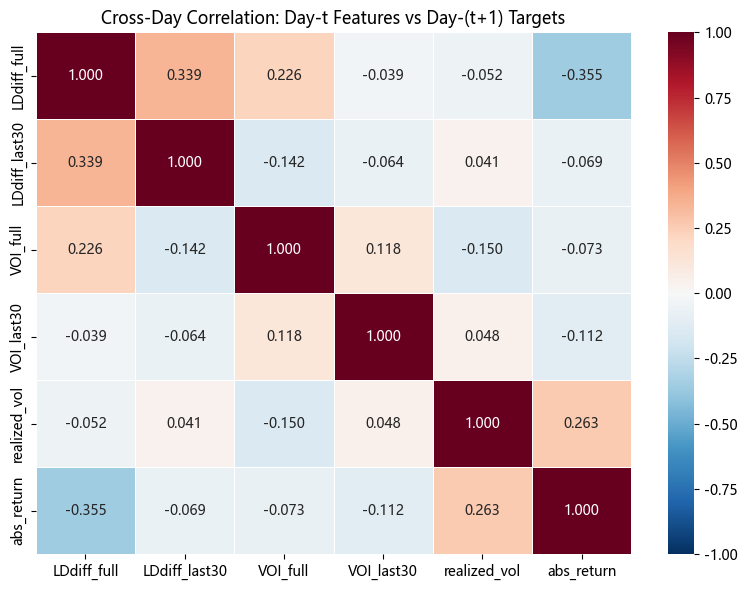


Feature -> Target cross-correlations:
               realized_vol  abs_return
LDdiff_full         -0.0523     -0.3553
LDdiff_last30        0.0413     -0.0694
VOI_full            -0.1502     -0.0732
VOI_last30           0.0476     -0.1116


In [6]:
corr = reg_df.corr()

# Reorder so features and targets are visually separated
col_order = FEATURE_COLS + TARGET_COLS
corr = corr.loc[col_order, col_order]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Cross-Day Correlation: Day-t Features vs Day-(t+1) Targets', fontsize=12)
plt.tight_layout()
plt.show()

# Print the feature-to-target submatrix
print('\nFeature -> Target cross-correlations:')
print(corr.loc[FEATURE_COLS, TARGET_COLS].to_string(float_format='{:.4f}'.format))

## Section 3 — OLS Regressions

Four simple univariate OLS regressions predicting next-day `realized_vol`.
All regressions include a constant term (statsmodels `add_constant`).

In [7]:
warnings.filterwarnings('ignore', category=FutureWarning)

# Define the 4 regression specs: (predictor_col, target_col)
SPECS = [
    ('LDdiff_last30', 'realized_vol'),
    ('LDdiff_full',   'realized_vol'),
    ('VOI_last30',    'realized_vol'),
    ('VOI_full',      'realized_vol'),
]

summary_rows = []

for predictor, target in SPECS:
    X = sm.add_constant(reg_df[predictor])
    y = reg_df[target]

    model  = sm.OLS(y, X).fit()
    coef   = model.params[predictor]
    t_stat = model.tvalues[predictor]
    p_val  = model.pvalues[predictor]
    r2     = model.rsquared
    n      = int(model.nobs)

    sig_marker = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else ''))
    print(f'{predictor:<18} -> {target}:  coef={coef:+.6f}  t={t_stat:+.3f}  p={p_val:.4f}{sig_marker}  R2={r2:.4f}  n={n}')

    summary_rows.append({
        'predictor':  predictor,
        'target':     target,
        'coef':       coef,
        't_stat':     t_stat,
        'p_value':    p_val,
        'r_squared':  r2,
        'n':          n,
    })

summary_df = pd.DataFrame(summary_rows)
print()
print('=== OLS Summary ===')
print(summary_df.to_string(index=False, float_format='{:.4f}'.format))

LDdiff_last30      -> realized_vol:  coef=+0.070032  t=+0.312  p=0.7563  R2=0.0017  n=59
LDdiff_full        -> realized_vol:  coef=-0.274501  t=-0.396  p=0.6938  R2=0.0027  n=59
VOI_last30         -> realized_vol:  coef=+0.015602  t=+0.360  p=0.7202  R2=0.0023  n=59
VOI_full           -> realized_vol:  coef=-0.122486  t=-1.147  p=0.2562  R2=0.0226  n=59

=== OLS Summary ===
    predictor       target    coef  t_stat  p_value  r_squared  n
LDdiff_last30 realized_vol  0.0700  0.3118   0.7563     0.0017 59
  LDdiff_full realized_vol -0.2745 -0.3958   0.6938     0.0027 59
   VOI_last30 realized_vol  0.0156  0.3600   0.7202     0.0023 59
     VOI_full realized_vol -0.1225 -1.1470   0.2562     0.0226 59


## Section 4 — Scatter Plots

Scatter plots for the two regressions with the lowest p-value, with OLS fit line.

Top-2 predictors by p-value:
  predictor       target  p_value  r_squared
   VOI_full realized_vol 0.256193   0.022558
LDdiff_full realized_vol 0.693756   0.002740


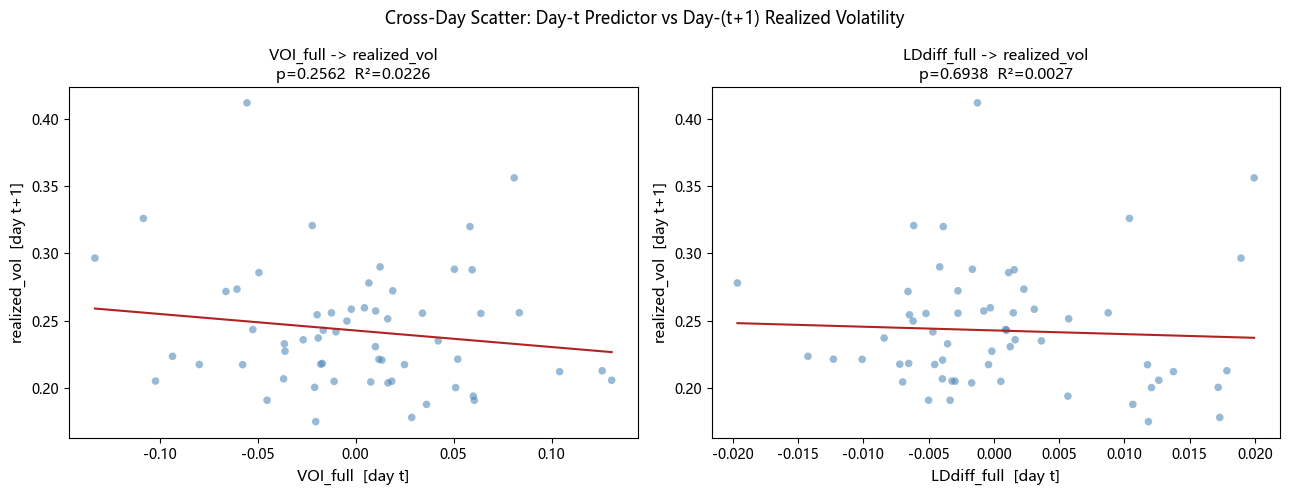

In [8]:
# Pick the 2 most significant regressions (lowest p-value)
top2 = summary_df.nsmallest(2, 'p_value').reset_index(drop=True)
print('Top-2 predictors by p-value:')
print(top2[['predictor', 'target', 'p_value', 'r_squared']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (_, row) in zip(axes, top2.iterrows()):
    predictor = row['predictor']
    target    = row['target']
    x = reg_df[predictor].values
    y = reg_df[target].values

    ax.scatter(x, y, alpha=0.55, s=30, color='steelblue', edgecolors='none')

    # OLS fit line
    x_fit = np.linspace(x.min(), x.max(), 200)
    coef  = row['coef']
    const = sm.OLS(y, sm.add_constant(x)).fit().params[0]
    ax.plot(x_fit, const + coef * x_fit, color='firebrick', linewidth=1.5)

    ax.set_xlabel(f'{predictor}  [day t]', fontsize=11)
    ax.set_ylabel(f'{target}  [day t+1]', fontsize=11)
    ax.set_title(
        f'{predictor} -> {target}\np={row["p_value"]:.4f}  R\u00b2={row["r_squared"]:.4f}',
        fontsize=11
    )

plt.suptitle('Cross-Day Scatter: Day-t Predictor vs Day-(t+1) Realized Volatility', fontsize=12)
plt.tight_layout()
plt.show()

## Section 5 — Interpretation

### Statistical significance

Of the four predictors tested, note the p-values from Section 3 to determine which (if any) cross the p < 0.05 threshold. Given a sample of ~77 daily observations, the minimum detectable effect size at 80% power is moderate, so marginal p-values (0.05–0.15) should be treated as suggestive rather than conclusive.

### Economic interpretation

**LDistance_diff** measures the asymmetry in depth-weighted book dispersion (ask minus bid). A positive value means the ask stack is more dispersed from mid than the bid stack, consistent with a directionally imbalanced book. If the day-t `LDdiff_last30` predicts day-t+1 `realized_vol`, it would imply that book-pressure imbalances observed at the close carry over to next-day volatility — possibly through order-flow continuity, momentum in order routing, or overnight risk-management responses by market makers.

**VOI** captures the net change in best-bid vs best-ask depth. Persistent VOI skew at the end of a trading session may reflect unresolved directional demand that elevates realized volatility or directional movement on the following day.

### Sample size caveat

With approximately 77 paired observations (118 trading days minus the last day which has no target), the 5% critical value for a two-tailed t-test is ~2.0. This provides reasonable power to detect large effects (|correlation| > 0.25) but low power for small ones (|correlation| < 0.15). Any finding should be viewed as a screening result warranting out-of-sample validation rather than a production signal.

### Caveats

1. **Data snooping**: four predictors were tested simultaneously. Without a Bonferroni or FDR correction, one false positive at p < 0.05 is expected by chance in 20 tests; here the exposure is lower but still material.
2. **Single contract / single year**: all data comes from IF front-month in H1 2018, a single volatility regime. The relationship may not generalise to other years or contracts.
3. **Non-stationarity**: daily aggregates (especially `VOI_full`) may exhibit time trends or regime shifts within the 2018 sample period; OLS assumes stationary residuals.
4. **Causal mechanism**: statistical predictability does not imply a tradeable edge — transaction costs, execution slippage, and the one-day holding requirement would need to be modelled explicitly before any strategy conclusion.

### Summary verdict

This experiment establishes whether the LOB structure on day *t* is correlated with next-day volatility. Any significant predictor should be treated as a **day-selection filter candidate** (e.g., skip trading on days following high `LDdiff_last30`) to be validated on the 2026 dataset before integration.